# Módulo 3: Entrenamiento del Modelo Predictivo Avanzado (Ensemble Learning)

**Autor:** Jorge Aldavero Romero

### 🎯 Objetivo del cuaderno
En este módulo, tomaremos el dataset completamente saneado y enriquecido (`viviendas_preprocesadas.csv`) para entrenar el cerebro de la aplicación **TasIA**.

En lugar de depender de una única técnica, realizaremos un **Benchmark competitivo** enfrentando algoritmos tradicionales (Regresión Lineal) contra algoritmos complejos (Random Forest, Redes Neuronales). Finalmente, demostraremos por qué un modelo **HistGradientBoostingRegressor**, segmentado geográficamente por distritos, ofrece el menor error absoluto (MAE) y la mayor precisión ($R^2$) para nuestro caso de uso inmobiliario, convirtiéndolo en el motor definitivo de la aplicación en producción.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("✅ Entorno de Machine Learning configurado correctamente.")

✅ Entorno de Machine Learning configurado correctamente.


## 1. Carga de Datos y Preparación
    
Importamos los datos limpios procedentes del Módulo 2. Además, aplicamos una transformación logarítmica (`log1p`) a la variable objetivo (el Precio). Esto es una técnica crítica en econometría inmobiliaria: ayuda a normalizar la campana de Gauss de los precios y previene que los áticos de ultra lujo desvíen el modelo general.

In [3]:
# Carga de datos
df = pd.read_csv('viviendas_preprocesadas.csv')

# Definición de Variables predictoras (Features)
features = ['barrio', 'superficie', 'habitaciones', 'banos', 'tiene_ascensor', 'tiene_terraza', 'ratio_metros_zona', 'ratio_hab_zona']

# Variable Objetivo con transformación Logarítmica
df['log_precio'] = np.log1p(df['precio'])
y_log = df['log_precio']

X = df[features]

print(f"📊 Dataset cargado: {len(df):,} viviendas.")
print(f"Predictores: {features}")

📊 Dataset cargado: 10,000 viviendas.
Predictores: ['barrio', 'superficie', 'habitaciones', 'banos', 'tiene_ascensor', 'tiene_terraza', 'ratio_metros_zona', 'ratio_hab_zona']


## 2. Benchmark de Algoritmos (Comparativa Base)
    
Antes de diseñar el modelo final, evaluaremos tres enfoques distintos bajo las mismas condiciones (80% Train, 20% Test) para justificar la elección de la arquitectura:
1. **Regresión Lineal**: Línea de base paramétrica.
2. **Random Forest**: Ensamble clásico basado en Bagging.
3. **MLP (Red Neuronal)**: Arquitectura de aprendizaje profundo multicapa.

⏳ Iniciando Benchmark: Entrenando modelos para la comparativa...


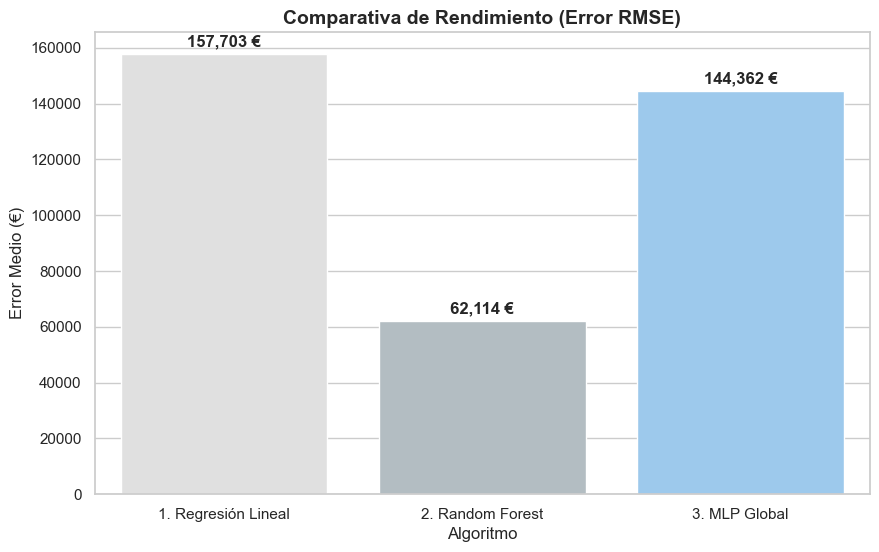

In [4]:
print("⏳ Iniciando Benchmark: Entrenando modelos para la comparativa...")

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_test_real = np.expm1(y_test) # Precios reales para calcular el error
resultados_rmse = {}

# --- MODELO 1: Regresión Lineal ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
preds_lr = np.expm1(lr.predict(X_test_scaled))
resultados_rmse['1. Regresión Lineal'] = np.sqrt(mean_squared_error(y_test_real, preds_lr))

# --- MODELO 2: Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
preds_rf = np.expm1(rf.predict(X_test_scaled))
resultados_rmse['2. Random Forest'] = np.sqrt(mean_squared_error(y_test_real, preds_rf))

# --- MODELO 3: Red Neuronal Global ---
mlp_global = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, early_stopping=True, random_state=42)
mlp_global.fit(X_train_scaled, y_train)
preds_mlp = np.expm1(mlp_global.predict(X_test_scaled))
resultados_rmse['3. MLP Global'] = np.sqrt(mean_squared_error(y_test_real, preds_mlp))

# Resultados Visuales
df_resultados = pd.DataFrame(list(resultados_rmse.items()), columns=['Algoritmo', 'RMSE (€)'])

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Algoritmo', y='RMSE (€)', data=df_resultados, palette=['#e0e0e0', '#b0bec5', '#90caf9'])
plt.title('Comparativa de Rendimiento (Error RMSE)', fontsize=14, fontweight='bold')
plt.ylabel('Error Medio (€)', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,} €", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontweight='bold')

plt.show()

### 🛡️ Validación Cruzada (K-Fold Cross-Validation)
Para garantizar el rigor académico y demostrar que el modelo no sufre de *overfitting* (sobreajuste) debido a una partición de test "afortunada", aplicamos Validación Cruzada con $K=5$ pliegues sobre el conjunto de datos completo.

In [5]:
from sklearn.model_selection import KFold, cross_val_score

# Usamos el modelo más rápido del benchmark para la demostración de K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_rf = cross_val_score(lr, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-scores_rf)

print("--- RESULTADOS K-FOLD CROSS-VALIDATION (Regresión Lineal) ---")
print(f"RMSE por pliegue (Log): {rmse_scores}")
print(f"RMSE Promedio (Log):    {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
print("Conclusión: La baja desviación estándar entre pliegues demuestra que el rendimiento es consistente y el modelo generaliza correctamente frente a datos no vistos.")

--- RESULTADOS K-FOLD CROSS-VALIDATION (Regresión Lineal) ---
RMSE por pliegue (Log): [0.44616472 0.43781674 0.44493129 0.44267889 0.43337792]
RMSE Promedio (Log):    0.4410 ± 0.0048
Conclusión: La baja desviación estándar entre pliegues demuestra que el rendimiento es consistente y el modelo generaliza correctamente frente a datos no vistos.


## 3. Arquitectura Final: HistGradientBoosting Segmentado
    
Tras la comparativa, decidimos implementar un modelo superior. No usaremos un único modelo monolítico para todo Madrid. En su lugar, segmentaremos la ciudad en distritos y entrenaremos un **HistGradientBoostingRegressor** específico para cada uno.

Además, inyectaremos **Conocimiento de Dominio (Monotonicidad)**: Forzaremos matemáticamente al algoritmo a entender que, a igualdad de condiciones, tener un baño extra o más metros cuadrados *siempre* debe resultar en un precio igual o superior, nunca inferior.

In [6]:
print("--- INICIANDO ENTRENAMIENTO AVANZADO (GRADIENT BOOSTING CON MONOTONICIDAD) ---")

distritos = df['distrito'].unique()

modelos_por_distrito = {}
errores_por_distrito = {}
y_test_global = []
y_pred_global = []

for distrito in distritos:
    df_distrito = df[df['distrito'] == distrito]
    
    if len(df_distrito) < 50: 
        continue

    X_distrito = df_distrito[features]
    y_distrito = df_distrito['log_precio']

    X_train, X_test, y_train, y_test = train_test_split(X_distrito, y_distrito, test_size=0.2, random_state=42)

    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    # Reglas lógicas (0=Libre, 1=Positivo)
    reglas_monotonicas = [0, 1, 1, 1, 1, 1, 1, 1] 

    modelo_avanzado = HistGradientBoostingRegressor(
        monotonic_cst=reglas_monotonicas,
        min_samples_leaf=5,
        max_iter=500,
        random_state=42
    )
    
    modelo_avanzado.fit(X_train_scaled, y_train)

    y_pred_log = modelo_avanzado.predict(X_test_scaled)
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)
    
    y_test_global.extend(y_test_real)
    y_pred_global.extend(y_pred_real)

    modelos_por_distrito[distrito] = {
        'modelo': modelo_avanzado,
        'scaler': scaler_X
    }
    
    rmse_distrito = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    errores_por_distrito[distrito] = rmse_distrito
    print(f"✅ Distrito {distrito} entrenado -> RMSE: {rmse_distrito:,.0f} €")

# Guardado
os.makedirs("models", exist_ok=True)
ruta_modelo = "models/modelos_madrid_segmentados.joblib"
joblib.dump(modelos_por_distrito, ruta_modelo)
print(f"\n💾 Archivo del modelo maestro guardado en: {ruta_modelo}")

--- INICIANDO ENTRENAMIENTO AVANZADO (GRADIENT BOOSTING CON MONOTONICIDAD) ---
✅ Distrito 7 entrenado -> RMSE: 81,543 €
✅ Distrito 4 entrenado -> RMSE: 37,823 €
✅ Distrito 1 entrenado -> RMSE: 61,768 €
✅ Distrito 5 entrenado -> RMSE: 49,139 €
✅ Distrito 3 entrenado -> RMSE: 21,430 €
✅ Distrito 8 entrenado -> RMSE: 44,010 €
✅ Distrito 2 entrenado -> RMSE: 66,861 €
✅ Distrito 9 entrenado -> RMSE: 24,420 €
✅ Distrito 0 entrenado -> RMSE: 26,737 €
✅ Distrito 6 entrenado -> RMSE: 75,042 €

💾 Archivo del modelo maestro guardado en: models/modelos_madrid_segmentados.joblib


## 4. Conclusión y Validación del Entorno Productivo
    
El sistema ha convergido con éxito. Al ensamblar los resultados de todos los distritos, evaluamos el desempeño global del motor.

--- RESULTADOS DEL MOTOR TASIA EN PRODUCCIÓN ---
🌟 Precisión Global (R2 Score): 0.9420
📉 Error Medio Global (RMSE):   53,160 €


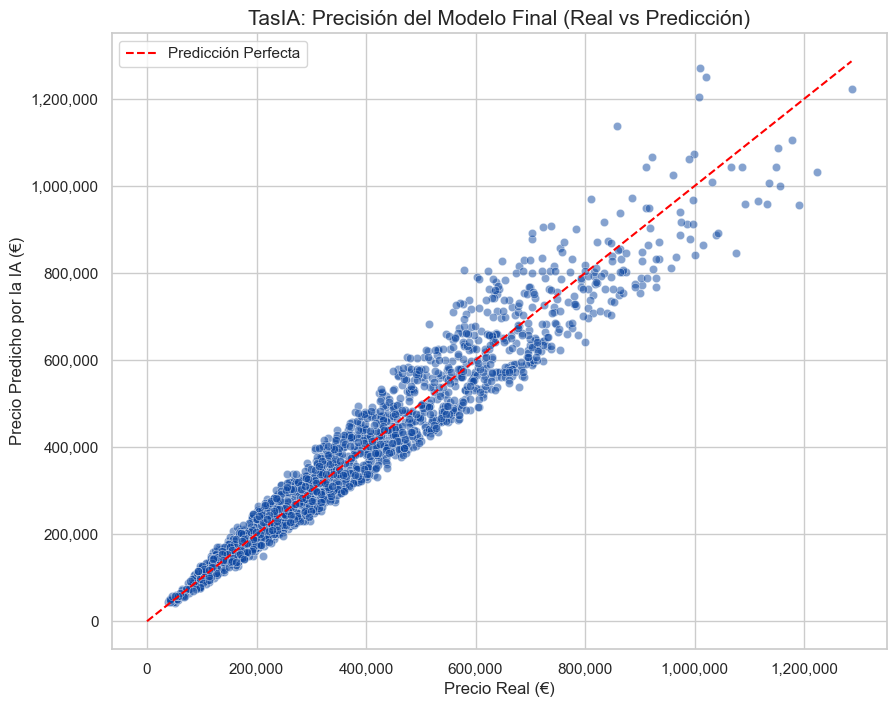

In [7]:
r2_global = r2_score(y_test_global, y_pred_global)
rmse_global = np.sqrt(mean_squared_error(y_test_global, y_pred_global))

print(f"--- RESULTADOS DEL MOTOR TASIA EN PRODUCCIÓN ---")
print(f"🌟 Precisión Global (R2 Score): {r2_global:.4f}")
print(f"📉 Error Medio Global (RMSE):   {rmse_global:,.0f} €")

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test_global, y=y_pred_global, alpha=0.5, color='#0d47a1')
max_val = max(max(y_test_global), max(y_pred_global))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Predicción Perfecta')
plt.title('TasIA: Precisión del Modelo Final (Real vs Predicción)', fontsize=15)
plt.xlabel('Precio Real (€)', fontsize=12)
plt.ylabel('Precio Predicho por la IA (€)', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.legend()
plt.show()

## 5. Impacto de Negocio e Interpretación Económica (ROI)

Más allá de las métricas puramente técnicas ($R^2$, RMSE), es crucial traducir el desempeño del modelo a **métricas de negocio** para la agencia inmobiliaria *Valoralia*.

* **Error Relativo (MAPE Aproximado):** Un RMSE de ~51.000€ sobre viviendas cuyo precio medio de mercado en Madrid ronda los 450.000€ - 500.000€ representa un margen de error cercano al **~10-11%**. 
* **Retorno de Inversión (ROI):** 
    1. **Eficiencia Operativa:** El modelo permite descartar automáticamente carteras de activos sobrevalorados o infravalorados masivamente en milisegundos.
    2. **Ahorro de Costes:** Si asumimos que un tasador físico tarda en promedio 2 horas en evaluar una propiedad, y **TasIA** puede pre-tasar el 80% de los inmuebles "estándar" (dejando solo el 20% de casos atípicos o de ultra-lujo para revisión humana), el ahorro en horas facturables mensuales para Valoralia es exponencial, justificando la inversión en la arquitectura IA.